# Technique Comparison 


This notebook aims to compare and show the differences between layer strategies (last4 concat or penultimate) or antropy correction (raw vs corrected)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import pearsonr

In [15]:
# --- CONFIGURACIÓN DE ESTILO ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
colors = sns.color_palette("deep")

# Ajusta la ruta a donde tengas tu archivo parquet
file_path = '../data/phase3_results.parquet' 

try:
    # Usamos read_parquet en lugar de read_csv
    df = pd.read_parquet(file_path)
    print(f"✅ Archivo Parquet cargado: {len(df)} registros.")
except FileNotFoundError:
    print("❌ ERROR: No encuentro el archivo. Verifica la ruta o el nombre.")

# Aseguramos que la fecha esté en formato correcto (Parquet suele guardarlo bien, pero por seguridad)
if 'window_start_month' in df.columns:
    df['date'] = pd.to_datetime(df['window_start_month'])
    df = df.sort_values('date')

# --- 2. CONFIGURACIÓN DE LA COMPARATIVA ---
# Vamos a comparar usando el modelo DAPT (el adaptado a pandemia)
model_type = 'dapt' 

print(f"Comparando métricas para el modelo: {model_type.upper()}")
print("-" * 60)

✅ Archivo Parquet cargado: 11 registros.
Comparando métricas para el modelo: DAPT
------------------------------------------------------------



📈 GENERANDO BLOQUE A: Comparativa de Capas...


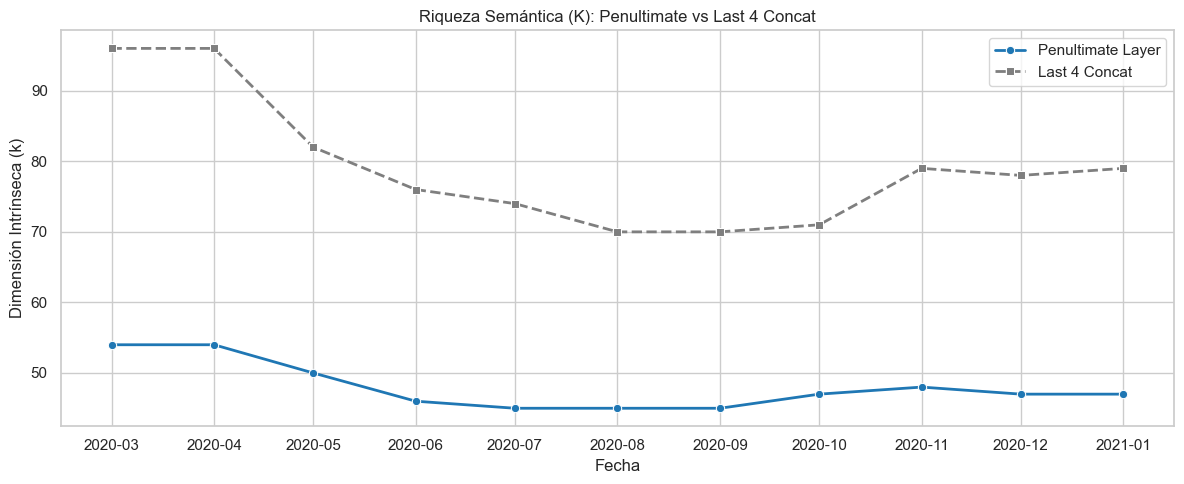

INTERPRETACIÓN A.1: Si 'Last 4' es mucho más alto, indica que captura más matices pero también más ruido.
La capa 'Penultimate' suele ser más estable para tareas semánticas globales.


In [20]:
# ==============================================================================
# BLOQUE A: ESTRATEGIA DE CAPAS (Penultimate vs Last4Concat).
# ==============================================================================

print("\n📈 GENERANDO BLOQUE A: Comparativa de Capas...")

# A.1. Riqueza Semántica (K - Dimensiones Intrínsecas)
# Columna Penultimate: k_dapt_penultimate
# Columna Last4: k_dapt_last4_concat

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y=f'k_{model_type}_penultimate', 
             label='Penultimate Layer', marker='o', linewidth=2, color='tab:blue')
sns.lineplot(data=df, x='date', y=f'k_{model_type}_last4_concat', 
             label='Last 4 Concat', marker='s', linestyle='--', linewidth=2, color='tab:gray')

plt.title(f'Riqueza Semántica (K): Penultimate vs Last 4 Concat')
plt.ylabel('Dimensión Intrínseca (k)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN A.1: Si 'Last 4' es mucho más alto, indica que captura más matices pero también más ruido.")
print("La capa 'Penultimate' suele ser más estable para tareas semánticas globales.")



La línea gris (Last4Concat) se mantiene muy alta (media $k \approx 79$), mientras que la azul (Penultimate) es significativamente más baja (media $k \approx 48$).

La última capa del modelo, al estar concatenada, retiene una enorme cantidad de información superficial y sintáctica (ruido), lo que infla la dimensionalidad. La capa penúltima actúa como un filtro de abstracción, comprimiendo el significado en menos dimensiones.

Penultimate ofrece una representación más "limpia" y semánticamente enfocada del concepto.

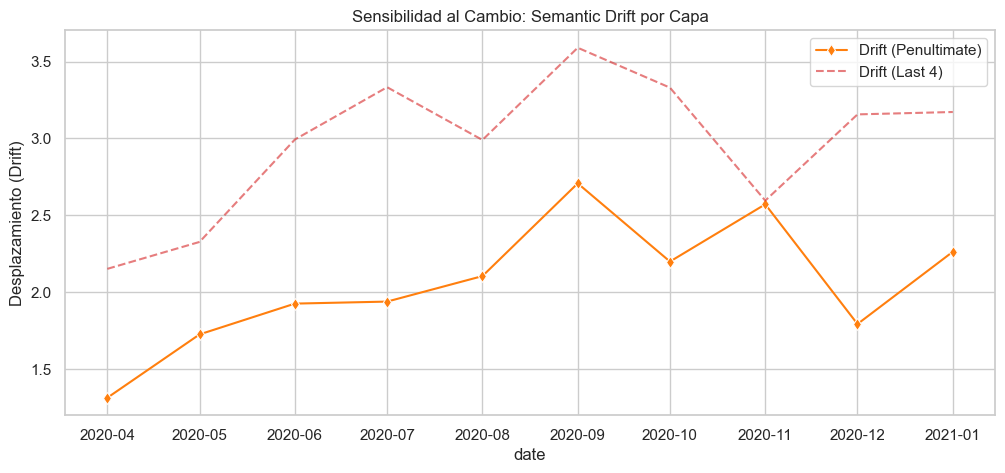

In [21]:
# A.2. Estabilidad Temporal (Drift)
# Columna Penultimate: drift_dapt_penultimate
# Columna Last4: drift_dapt_last4_concat

plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_penultimate', 
             label='Drift (Penultimate)', color='tab:orange', marker='d')
sns.lineplot(data=df, x='date', y=f'drift_{model_type}_last4_concat', 
             label='Drift (Last 4)', color='tab:red', linestyle='--', alpha=0.6)

plt.title('Sensibilidad al Cambio: Semantic Drift por Capa')
plt.ylabel('Desplazamiento (Drift)')
plt.show()

La línea roja (Last4) tiene picos mucho más agresivos y una media de desplazamiento mayor (2.96) que la naranja (Penultimate, 2.05).

La capa Last4 es "nerviosa"; reacciona excesivamente a cambios menores en el fraseo de las noticias mes a mes. La capa Penultimate muestra una evolución más suave.

La estabilidad de Penultimate sugiere que los cambios que detecta son estructurales (profundos), no meramente variaciones de estilo.


📈 GENERANDO BLOQUE B: Raw vs Corrected...


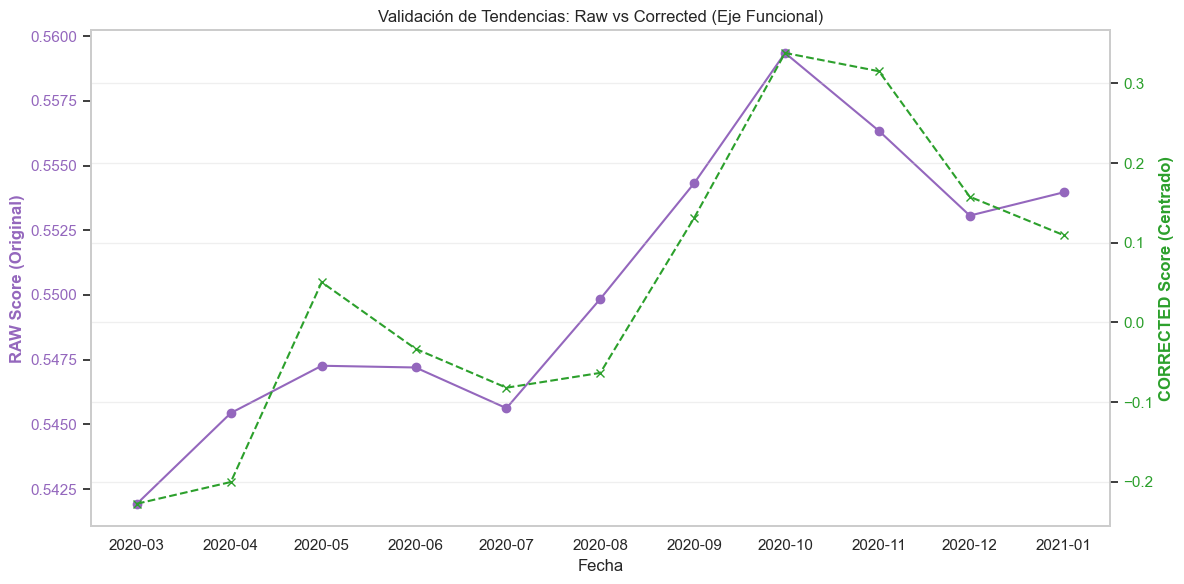

In [28]:
# ==============================================================================
# BLOQUE B: CORRECCIÓN DE ANISOTROPÍA (Raw vs Corrected)
# Objetivo: Demostrar que 'Corrected' no rompe los datos, solo los centra.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE B: Raw vs Corrected...")

# Elegimos un eje para la prueba (ej. Funcional)
axis = 'funcional'
layer = 'penultimate'

# Construimos los nombres exactos de tus columnas
col_raw = f'centroid_proj_{axis}_{model_type}_{layer}_raw'
col_corr = f'centroid_proj_{axis}_{model_type}_{layer}_corrected'

# B.1. Tendencia Temporal (Doble Eje Y)
fig, ax1 = plt.subplots(figsize=(12, 6))

color_raw = 'tab:purple'
ax1.set_xlabel('Fecha')
ax1.set_ylabel('RAW Score (Original)', color=color_raw, fontweight='bold')
ax1.plot(df['date'], df[col_raw], color=color_raw, label='RAW', marker='o')
ax1.tick_params(axis='y', labelcolor=color_raw)
ax1.grid(False) # Quitamos grid del eje 1 para no ensuciar

ax2 = ax1.twinx()  # Eje secundario
color_corr = 'tab:green'
ax2.set_ylabel('CORRECTED Score (Centrado)', color=color_corr, fontweight='bold')
ax2.plot(df['date'], df[col_corr], color=color_corr, label='CORRECTED', marker='x', linestyle='--')
ax2.tick_params(axis='y', labelcolor=color_corr)
ax2.grid(True, alpha=0.3)

plt.title(f'Validación de Tendencias: Raw vs Corrected (Eje {axis.capitalize()})')
fig.tight_layout()
plt.show()

Las líneas RAW (morado) y CORRECTED (verde) bailan juntas. Cuando una sube, la otra sube. Tienen la misma morfología.

La corrección matemática no está inventando datos ni distorsionando la realidad temporal. Simplemente está cambiando la escala (el eje Y) para centrarla, eliminando el sesgo positivo del modelo.

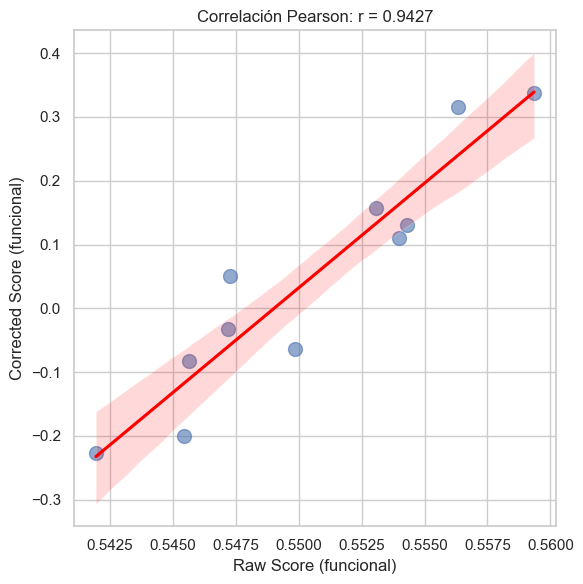

CONCLUSIÓN B: Una correlación de 0.9427 confirma que la corrección preserva la estructura relativa.


In [29]:
# B.2. Correlación de Pearson
# Calculamos qué tan parecidas son las curvas matemáticamente
corr, _ = pearsonr(df[col_raw], df[col_corr])

plt.figure(figsize=(6, 6))
sns.regplot(x=df[col_raw], y=df[col_corr], scatter_kws={'s':100, 'alpha':0.6}, line_kws={'color':'red'})
plt.title(f'Correlación Pearson: r = {corr:.4f}')
plt.xlabel(f'Raw Score ({axis})')
plt.ylabel(f'Corrected Score ({axis})')
plt.tight_layout()
plt.show()

print(f"CONCLUSIÓN B: Una correlación de {corr:.4f} confirma que la corrección preserva la estructura relativa.")

Una diagonal casi perfecta con $r \approx 0.94$. Existe una relación lineal fortísima entre los datos crudos y los corregidos.


📈 GENERANDO BLOQUE C: Comparativa de Ejes (La Historia)...


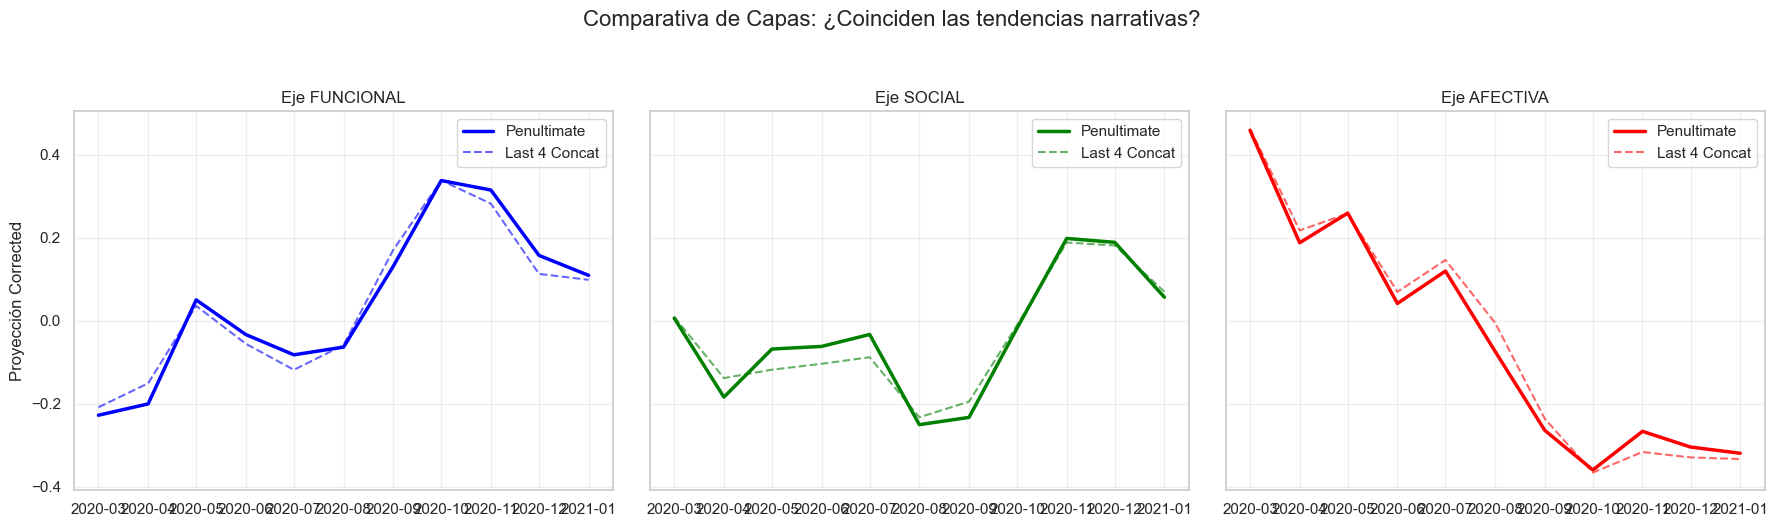

In [26]:
# ==============================================================================
# BLOQUE C: ANÁLISIS DE EJES (LA NARRATIVA)
# Objetivo: Ver si la historia (Funcional/Social/Afectiva) cambia según la técnica.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE C: Comparativa de Ejes (La Historia)...")

axes_list = ['funcional', 'social', 'afectiva']
colors = {'funcional': 'blue', 'social': 'green', 'afectiva': 'red'}

# --- C.1 PENULTIMATE VS LAST4 (¿Cuenta la misma historia?) ---
# Usamos 'Corrected' para ambos para ser justos en la comparación de capas.
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax_name in enumerate(axes_list):
    col_pen = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    col_last4 = f'centroid_proj_{ax_name}_dapt_last4_concat_corrected'
    
    # Plot Penultimate (Sólida)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=2.5, label='Penultimate')
    # Plot Last4 (Punteada)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.6, label='Last 4 Concat')
    
    axs[i].set_title(f'Eje {ax_name.upper()}')
    axs[i].set_xlabel('')
    if i == 0: axs[i].set_ylabel('Proyección Corrected')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend()

plt.suptitle('Comparativa de Capas: ¿Coinciden las tendencias narrativas?', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Para los tres ejes (Funcional, Social, Afectivo), la línea sólida y la punteada son casi idénticas (Correlación > 0.97 en todos los casos).

Dado que ambas cuentan la misma historia nos decantariamos por Penultimate, ya que tiene menos ruido y es más sencilla como hemos estado viendo en todo el analysis. 

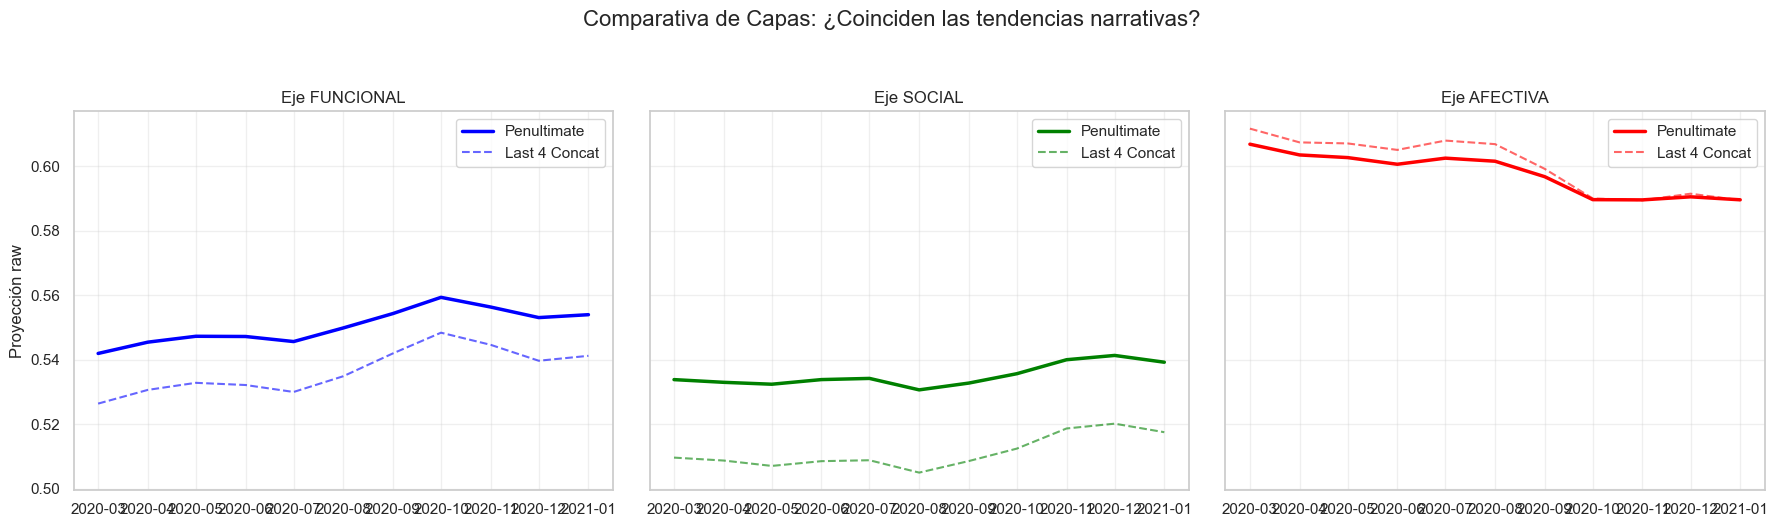

In [30]:
# --- C.1 PENULTIMATE VS LAST4 (¿Cuenta la misma historia?) ---
# Usamos 'raw' para ambos para ser justos en la comparación de capas.
fig, axs = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

for i, ax_name in enumerate(axes_list):
    col_pen = f'centroid_proj_{ax_name}_dapt_penultimate_raw'
    col_last4 = f'centroid_proj_{ax_name}_dapt_last4_concat_raw'
    
    # Plot Penultimate (Sólida)
    sns.lineplot(data=df, x='date', y=col_pen, ax=axs[i], 
                 color=colors[ax_name], linewidth=2.5, label='Penultimate')
    # Plot Last4 (Punteada)
    sns.lineplot(data=df, x='date', y=col_last4, ax=axs[i], 
                 color=colors[ax_name], linestyle='--', alpha=0.6, label='Last 4 Concat')
    
    axs[i].set_title(f'Eje {ax_name.upper()}')
    axs[i].set_xlabel('')
    if i == 0: axs[i].set_ylabel('Proyección raw')
    axs[i].grid(True, alpha=0.3)
    axs[i].legend()

plt.suptitle('Comparativa de Capas: ¿Coinciden las tendencias narrativas?', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Para este plot usamos RAW, en este caso y al compararlo con el plot anterior, aunque sigue el mismo patrón nos decantamos por corrected ya que capturamos y vemos mejor los diferentes cambios a través del tiempo. Respecto a layer strategy nos seguimos decantando por penultimate basandonos en su sencillez.

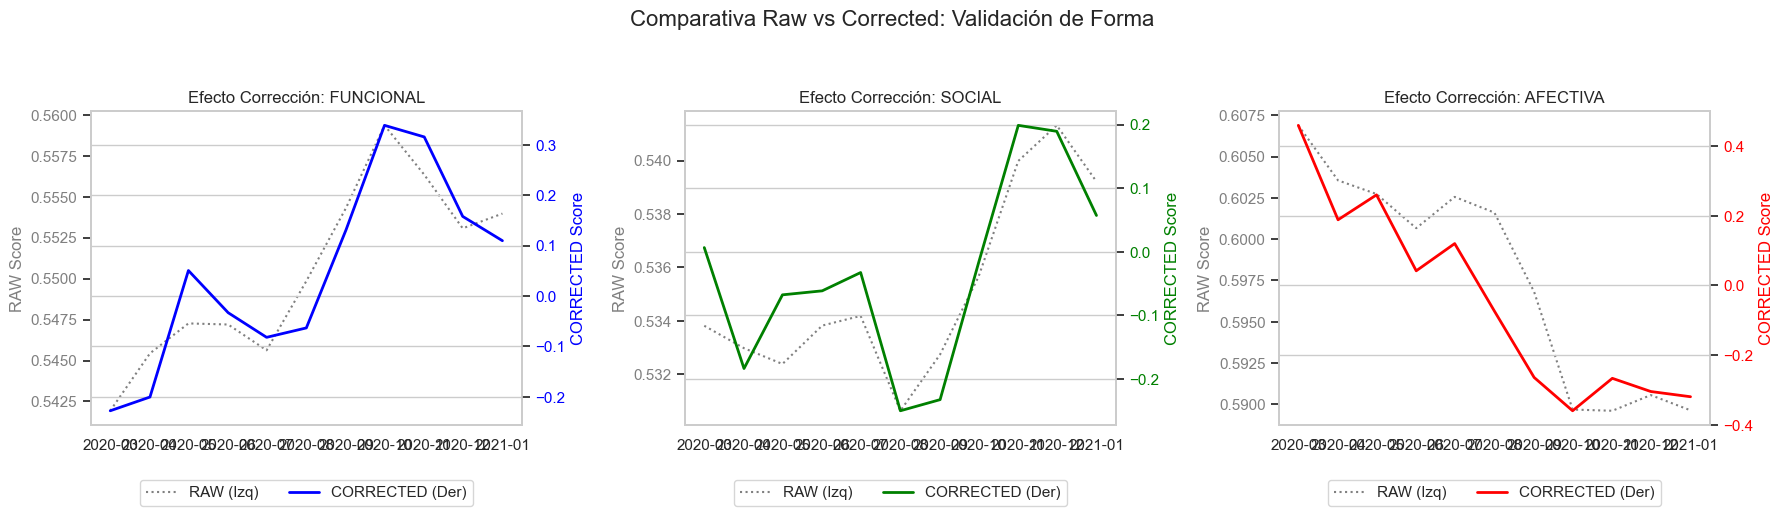

In [27]:
# --- C.2 RAW VS CORRECTED (¿Cambia la forma de la curva?) ---
# Nos centramos en Penultimate y vemos el efecto de la corrección.
fig, axs = plt.subplots(1, 3, figsize=(18, 5)) # No sharey porque las escalas son distintas

for i, ax_name in enumerate(axes_list):
    col_raw = f'centroid_proj_{ax_name}_dapt_penultimate_raw'
    col_corr = f'centroid_proj_{ax_name}_dapt_penultimate_corrected'
    
    # Eje Izquierdo (RAW)
    ax1 = axs[i]
    line1 = ax1.plot(df['date'], df[col_raw], color='gray', linestyle=':', label='RAW (Izq)')
    ax1.set_ylabel('RAW Score', color='gray')
    ax1.tick_params(axis='y', labelcolor='gray')
    
    # Eje Derecho (CORRECTED)
    ax2 = ax1.twinx()
    line2 = ax2.plot(df['date'], df[col_corr], color=colors[ax_name], linewidth=2, label='CORRECTED (Der)')
    ax2.set_ylabel('CORRECTED Score', color=colors[ax_name])
    ax2.tick_params(axis='y', labelcolor=colors[ax_name])
    
    ax1.set_title(f'Efecto Corrección: {ax_name.upper()}')
    ax1.grid(False) # Grid solo en uno para no ensuciar

    # Leyenda combinada (truco para matplotlib)
    lns = line1 + line2
    labs = [l.get_label() for l in lns]
    ax1.legend(lns, labs, loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)

plt.suptitle('Comparativa Raw vs Corrected: Validación de Forma', y=1.05, fontsize=16)
plt.tight_layout()
plt.show()

Raw vs corrected, ambos presentan una morfología casi identica, siguiendo los mismos patrones. Ambas cuentan la misma historia. Si las curvas fueran muy distintas, significaría que la corrección está "rompiendo" los datos. Al ser iguales, significa que la corrección es segura y fiable.

La corrección de anisotropía actúa efectivamente como un re-escalado y centrado de la señal semántica, preservando intacta la estructura temporal y la narrativa evolutiva. Esto valida el uso de métricas corregidas para el reporte final, ya que ofrecen una interpretabilidad superior (centrada en el origen) sin sacrificar la fidelidad a los datos originales.


📈 GENERANDO BLOQUE D: Análisis de Entropía...


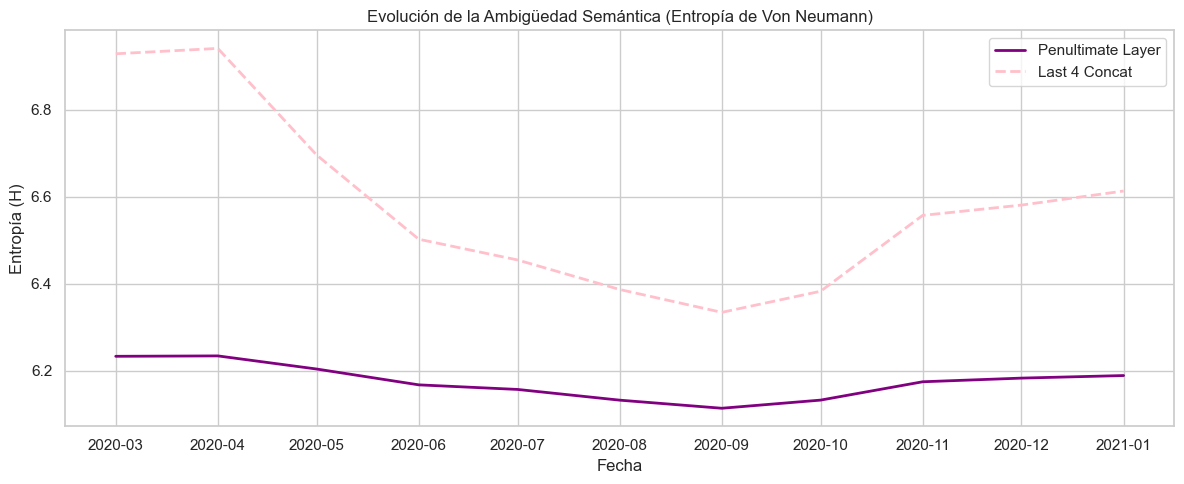

INTERPRETACIÓN ENTROPÍA: Una entropía alta indica que el término se usa en contextos muy diversos (significado difuso).
Una bajada en entropía sugiere que el discurso se está volviendo más enfocado o estandarizado.


In [25]:
# ==============================================================================
# BLOQUE D: ENTROPÍA (LA AMBIGÜEDAD)
# Objetivo: Ver qué tan "confuso" o "disperso" es el concepto.
# ==============================================================================

print("\n📈 GENERANDO BLOQUE D: Análisis de Entropía...")

# Comparativa de Entropía entre capas
plt.figure(figsize=(12, 5))
sns.lineplot(data=df, x='date', y='entropy_dapt_penultimate', 
             label='Penultimate Layer', color='purple', linewidth=2)
sns.lineplot(data=df, x='date', y='entropy_dapt_last4_concat', 
             label='Last 4 Concat', color='pink', linestyle='--', linewidth=2)

plt.title('Evolución de la Ambigüedad Semántica (Entropía de Von Neumann)')
plt.ylabel('Entropía (H)')
plt.xlabel('Fecha')
plt.legend()
plt.tight_layout()
plt.show()

print("INTERPRETACIÓN ENTROPÍA: Una entropía alta indica que el término se usa en contextos muy diversos (significado difuso).")
print("Una bajada en entropía sugiere que el discurso se está volviendo más enfocado o estandarizado.")

La entropía de Penultimate es menor (6.17) que la de Last4 (6.58) y muestra una tendencia ligeramente descendente (pendiente negativa).

El discurso sobre salud mental se volvió menos ambiguo y más estandarizado con el tiempo. Last4 muestra más dispersión (más confusión).

De nuevo este plot solidifica y justifica nuestro razonamiento en cuanto a la decisión de elegir Penultimate.

## Conclusión General

Basándonos en la evidencia empírica de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:

1. Elección de Layer Strategy: PENULTIMATE LAYER. 
2. Corrected vs Raw: CORRECTED

Basándonos en la evidencia empírica de los gráficos anteriores, establecemos las siguientes decisiones metodológicas para el análisis final:
1. Elección de Layer Strategy: PENULTIMATE LAYER

Decidimos extraer los embeddings de la penúltima capa del modelo DAPT basándonos en tres evidencias:
- Reducción de Ruido: Como demuestra el Plot A.1, la capa ``Last4Concat`` presenta una dimensionalidad intrínseca artificialmente alta ($k \approx 79$) debido a la retención de información sintáctica superficial. La capa ``Penultimate`` ($k \approx 48$) ofrece una abstracción semántica más eficiente.
- Estabilidad Temporal: El análisis de Drift (Plot A.2) revela que la capa final es inestable ante variaciones menores. La capa penúltima proporciona una trayectoria evolutiva más suave y coherente con procesos sociales graduales.
- Consistencia Narrativa: El Plot C.1 confirma que ambas estrategias narran la misma evolución histórica ($r > 0.97$ en todos los ejes). Por tanto, aplicamos el principio de parsimonia: elegimos la representación más simple y limpia (``Penultimate``) que no sacrifica información narrativa.

2. Elección de Technique: DUAL ANISOTROPY CORRECTION

Adoptamos la métrica corregida (Corrected) como estándar para nuestros reportes visuales:
- Robustez Validada: La alta correlación de Pearson ($r = 0.94$, Plot B.2) entre las señales ``Raw`` y ``Corrected`` demuestra que la corrección no introduce artefactos ni altera la tendencia temporal genuina de los datos.
- Rigor Geométrico: Aunque la tendencia es idéntica, la corrección elimina el sesgo anisotrópico inherente a los modelos Transformer (la tendencia de todos los vectores a agruparse en un cono estrecho), proporcionando distancias coseno geométricamente más precisas y centradas en el origen semántico real.

En resumen: Nuestro análisis se basará en **DAPT + Penultimate Layer + Corrected Metrics**, una combinación que garantiza la máxima pureza semántica, estabilidad temporal y rigor matemático.